# Prior elicitation

This notebook derives the priors for the *Cordylophora caspia* functional-response
model (`../src/model.py`) **before conditioning on the reanalyzed data**. Every prior
is elicited on an interpretable, biologically meaningful quantity (a capture fraction,
a maximum consumption, a fold-difference between levels), stated as a claim with an
explicit probability, and mapped to the maximum-entropy distribution consistent with
that claim via PreliZ's `maxent`. Each prior is then audited in outcome space to
confirm the encoded distribution matches the stated claim.

This notebook has **no dependency on the reanalyzed dataset** — no data is loaded here.
That is deliberate: it is the notebook's own evidence that these priors were set from
background knowledge alone, not read off the data they will condition on.

> **Status note.** Only the attack-rate family (`a0`, `a_prey`, `a_sal`, `a_int`) has
> been elicited so far. The handling-time family (`h0`, `h_prey`, `h_sal`, `h_int`) and
> the process-dispersion term (`tau`) are discussed conceptually in the project write-up
> but have not yet been run through `maxent` here — see the TODO at the end of this
> notebook. **The model as currently built and sampled (`../src/model.py`,
> `02_sampling_and_inference.ipynb`) does not yet use the elicited attack-rate priors
> below** — it still uses the earlier, pre-elicitation values. Reconciling the two is
> an open task.

In [10]:
import numpy as np
import pymc as pm
import preliz as pz
from scipy.special import expit  # inverse logit, for outcome-space audits
import matplotlib.pyplot as pp


## Model context

The quantities being elicited are the two Holling disc-equation parameters, on the
link scale they enter the model:

$$\mu = \frac{\alpha \cdot N_0}{1 + \alpha \cdot h \cdot N_0}$$

where $\alpha$ (attack rate) is modeled on the logit scale and $h$ (handling time) on
the log scale, each as a grand mean plus prey, salinity, and prey$\times$salinity
effects (see `02_sampling_and_inference.ipynb` for the full generative-process
derivation). This notebook elicits priors for the grand means and effect scales
directly, without reference to any fitted model or observed cell.

## Elicitation approach

Priors are elicited on **interpretable quantities** -- capture fractions, maximum
consumption, fold-differences between levels -- never on coefficient scales, where no
one holds intuitions. Each claim is stated as an interval with a probability, and the
**maximum-entropy** distribution consistent with that claim is adopted (least-committal
given the stated information; PreliZ `maxent`). Every prior is then **audited in
outcome space** (a capture fraction via `invlogit`, an asymptote via `exp` then `1/h`)
to confirm the claim we wrote is the claim we encoded.

Two devices make effect priors defensible:

- **Fold-change &rarr; $\sigma$; identity.** For a `ZeroSumNormal($\sigma$;)`, any pairwise
  contrast between levels has SD $\sigma \sqrt{2}$ (exactly, for any number of levels).
  So a pre-data belief "two levels differ up to *R*-fold" maps directly to
  $\sigma = ln(R) / (1.96 \sqrt{2})$. The reviewer argues with *R*, a
  biological fold-change -- not with a sigma.
- **Differentiated salinity vs. prey widths.** Salinity effects are given *tighter*
  priors than prey effects on both parameters, because the euryhaline literature does
  real work here: *C. caspia* and all three prey tolerate 5-40 g L&#8315;&#185;
  (Folino-Rorem & Renken 2018; Nandini et al. 2026), and the experiment sits at
  10-30 g L&#8315;&#185; -- well inside tolerance. A priori we therefore expect
  salinity to shift capture and handling *less* than prey identity does. This is an
  explicit, citable commitment, and its influence on every reported conclusion is
  quantified post-fit by power-scaling sensitivity (`psense`).

Two priors are deliberately **not** literature-anchored, and we say why:

- **`a0` (grand-mean capture fraction) is elicited from ignorance, not literature.**
  No study reports a single "capture fraction" for this predator, and inventing one
  would be false precision. We instead encode symmetry and boundedness only: median
  fraction 0.5, 95% within (0.05, 0.95) -- the maximum-entropy statement of "it is a
  fraction and could be anywhere." Letting the data locate it is the honest posture.
- **`h0` (grand-mean handling time) is anchored to a transparent heuristic, not
  tightened on a related study.** Handling a small zooplankter takes on the order of
  minutes; over a 2-h assay this caps processing at tens of prey (&asymp;40). The
  nearest related-cnidarian datum -- *Hydra* preying on cladocerans (Rivera-De la
  Parra et al. 2016) -- is only loosely commensurate (solitary freshwater polyp,
  cladoceran prey, demographic rather than functional-response measurement), so it
  corroborates the order of magnitude but does **not** justify a narrow prior. `h0`
  is therefore kept deliberately broad and validated downstream by the prior
  predictive on implied prey consumption, not by tightening.

## Attack rate family: `a0`, `a_prey`, `a_sal`, `a_int`

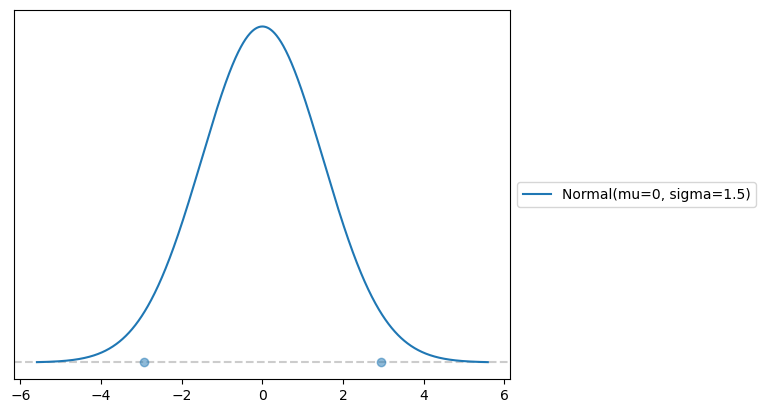

In [8]:
# fold-change -> ZeroSumNormal sigma  (contrast SD = sigma*sqrt(2))
zsn_sigma = lambda R: np.log(R) / (1.96 * np.sqrt(2))

# --- a0: grand-mean capture fraction, elicited from IGNORANCE ----------------
# Claim: it is a fraction; median 0.5; 95% within (0.05, 0.95); symmetric.
(a0_prior, axs) = pz.maxent(pz.Normal(mu=0), np.log(0.05/0.95), np.log(0.95/0.05), 0.95)
# -> Normal(0, 1.50).  AUDIT in outcome space (fraction):
#pz.Normal(0, 1.502).plot_pdf()          # then mentally invlogit: mass fills (0,1), peaks mid

# --- a_prey: prey identity moves capture the MOST -----------------------------
# Claim: two prey can differ up to ~7x in capture ODDS (size, escape, armor;
#        Fulton 1963, nematocyst capture of chemically-recognized prey).
a_prey_sigma = zsn_sigma(7)             # -> 0.70

# --- a_sal: salinity moves capture LESS (euryhaline, in-range) -----------------
# Claim: salinity shifts capture odds up to ~3x across 10-30 g/L
#        (tolerance 5-40; Folino-Rorem & Renken 2018).
a_sal_sigma = zsn_sigma(3)              # -> 0.40

# --- a_int: interaction is a second-order correction --------------------------
a_int_sigma = 0.5 * a_prey_sigma        # -> 0.35  (background lean toward additivity)


a_prey: sigma=0.70  95% |odds ratio|=7.0x  (claim: 7x)
a_sal: sigma=0.40  95% |odds ratio|=3.0x  (claim: 3x)
a_int: sigma=0.35  95% |odds ratio|=2.6x  (claim: ~half of a_preyx)


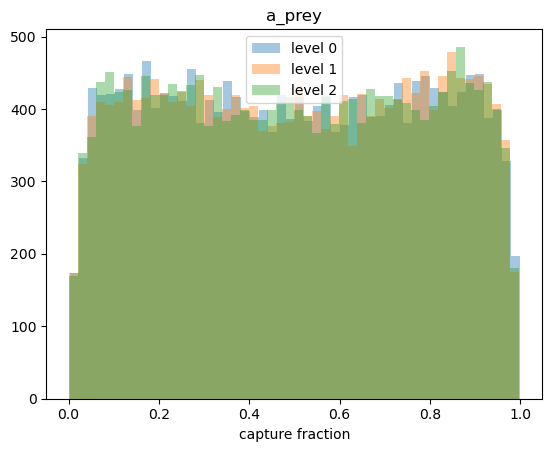

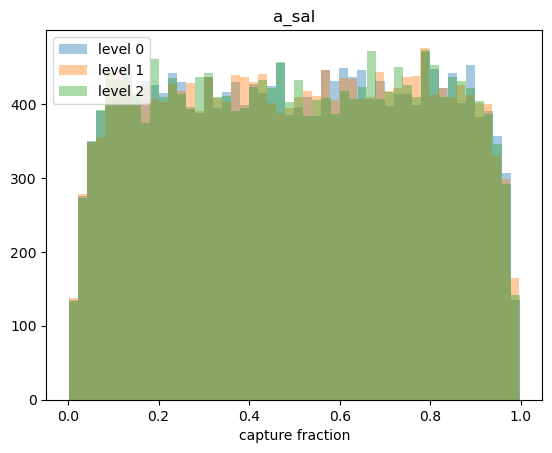

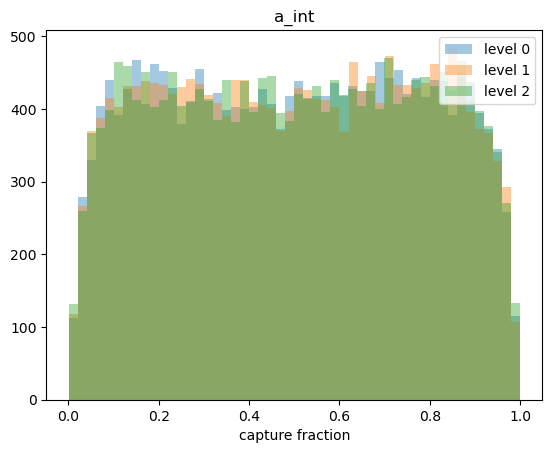

In [13]:
def audit_zsn(sigma, R_claim, label, n=3):
    a0_s = a0_prior.rvs(20000)
    u = pm.draw(pm.ZeroSumNormal.dist(sigma=sigma, shape=n), draws=20000)
    frac = expit(a0_s[:, None] + u)          # capture fraction per level, (20000, n)
    ratio = np.exp(np.percentile(np.abs(u[:, 0] - u[:, 1]), 95))
    print(f"{label}: sigma={sigma:.2f}  95% |odds ratio|={ratio:.1f}x  (claim: {R_claim}x)")
    pp.figure()
    for i in range(n):
        pp.hist(frac[:, i], bins=50, alpha=0.4, label=f"level {i}")
    pp.xlabel("capture fraction"); pp.legend(); pp.title(label)

audit_zsn(a_prey_sigma, 7, "a_prey")
audit_zsn(a_sal_sigma, 3, "a_sal")
audit_zsn(a_int_sigma, "~half of a_prey", "a_int")

Text(0.5, 0, 'capture fraction')

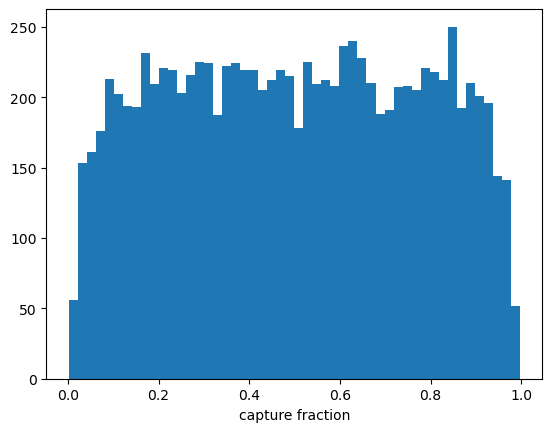

In [9]:
samples = a0_prior.rvs(10000)
pp.hist(expit(samples), bins=50)
pp.xlabel('capture fraction')

In [14]:
print(f"a0     ~ Normal(0, {a0_prior.sigma:.2f})")
print(f"a_prey ~ ZSN({a_prey_sigma:.2f})  |  a_sal ~ ZSN({a_sal_sigma:.2f})  |  a_int ~ ZSN({a_int_sigma:.2f})")

# AUDIT: does the a_prey claim really imply ~7x contrasts? simulate the contrast
c = np.random.default_rng(0).normal(0, a_prey_sigma*np.sqrt(2), 40000)   # level-vs-level
print(f"a_prey implied 95% capture-odds ratio: {np.exp(np.percentile(c,97.5)):.1f}x")  # ~7


a0     ~ Normal(0, 1.50)
a_prey ~ ZSN(0.70)  |  a_sal ~ ZSN(0.40)  |  a_int ~ ZSN(0.35)
a_prey implied 95% capture-odds ratio: 7.0x


## TODO: handling-time family and process dispersion

Not yet elicited in this notebook:

- `h0` -- grand-mean handling time (heuristic: minutes-per-prey &times; assay duration
  &rarr; asymptote of order tens of prey; deliberately kept broad, not literature-tightened
  -- see rationale above).
- `h_prey`, `h_sal`, `h_int` -- handling-time effect scales, following the same
  fold-change identity as the attack-rate family, with `h_sal` tighter than `h_prey`
  per the differentiated-widths rationale above.
- `tau` -- process/lack-of-fit dispersion in the measurement layer.

Until these are run through `maxent` and audited here, `../src/model.py` continues to
use its original (pre-elicitation) values for these parameters.

h0 ~ Normal(log(1/40), 0.74)
A=1/h implied p1/50/99: [  7.  40. 220.]


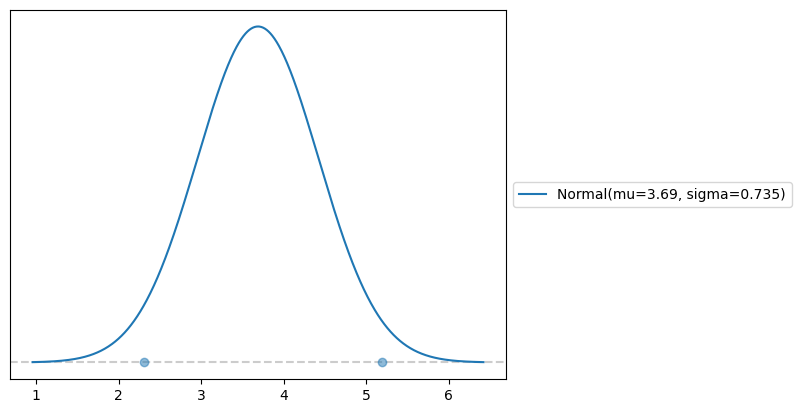

In [15]:
# --- h0: grand-mean handling time, BROAD heuristic ----------------------------
# Claim: max consumption A=1/h is order tens of prey over the 2h assay;
#        95% within (10, 180), median ~40. Rivera-De la Parra et al. 2016 (Hydra
#        on cladocerans) corroborates order of magnitude only -- not commensurate
#        enough (different predator lifestyle, prey taxon, fixed-duration count
#        vs. rate) to tighten further.
h0_prior = pz.Normal(mu=np.log(40))
pz.maxent(h0_prior, np.log(10), np.log(180), 0.95)
print(f"h0 ~ Normal(log(1/40), {h0_prior.sigma:.2f})")

# AUDIT in outcome space: implied asymptote A = 1/h
A = np.exp(np.random.default_rng(1).normal(np.log(40), h0_prior.sigma, 40000))
print(f"A=1/h implied p1/50/99: {np.percentile(A,[1,50,99]).round(0)}")

In [16]:
# --- h_prey/h_sal/h_int: same fold-change logic as attack rate, tighter overall
# (background: handling shifts expected more modest than capture shifts) ------
h_prey_sigma = zsn_sigma(4)      # prey differ up to ~4x in handling (exoskeleton vs lorica)
h_sal_sigma  = zsn_sigma(2.3)    # salinity up to ~2.3x (euryhaline, tighter)
h_int_sigma  = 0.5 * h_prey_sigma

print(f"h_prey ~ ZSN({h_prey_sigma:.2f})  |  h_sal ~ ZSN({h_sal_sigma:.2f})  |  h_int ~ ZSN({h_int_sigma:.2f})")

# AUDIT: implied handling-time ratio (h is log-linked, so contrast -> direct fold-change)
c = np.random.default_rng(0).normal(0, h_prey_sigma*np.sqrt(2), 40000)
print(f"h_prey implied 95% handling-time ratio: {np.exp(np.percentile(np.abs(c),95)):.1f}x")

h_prey ~ ZSN(0.50)  |  h_sal ~ ZSN(0.30)  |  h_int ~ ZSN(0.25)
h_prey implied 95% handling-time ratio: 4.0x


tau ~ Gamma(2.66, 0.99)  mean~2.7


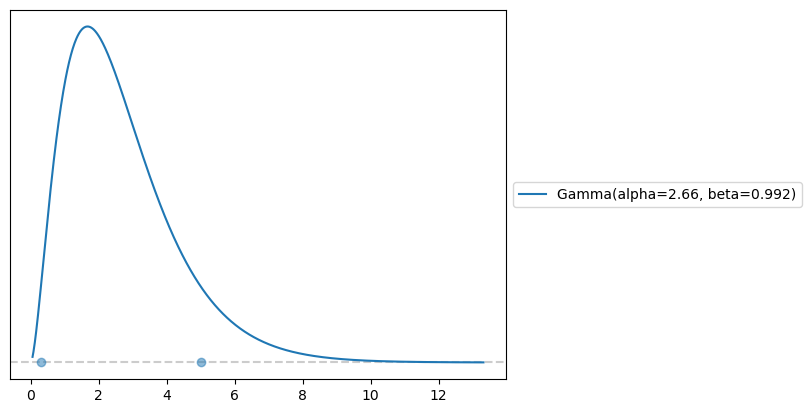

In [17]:
# --- tau: process/lack-of-fit SD, order a few prey -----------------------------
tau_prior = pz.Gamma()
pz.maxent(tau_prior, 0.3, 5.0, 0.90)
print(f"tau ~ Gamma({tau_prior.params[0]:.2f}, {tau_prior.params[1]:.2f})  mean~{tau_prior.mean():.1f}")